In [ ]:
!pip install gensim
!pip install Levenshtein

  Using cached levenshtein-0.27.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (3.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 47.6 MB/s eta 0:00:00


In [ ]:
# # Path to your file
# file_path = "/content/Book1.txt"  # Change to your actual file path

# # Step 1: Read the file
# with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
#     text = f.read()

# # Step 2: Convert all text to lowercase
# lower_text = text.lower()

# # Step 3: Overwrite the original file (or save to new file)
# with open('/content/book.txt', 'w', encoding='utf-8') as f:
#     f.write(lower_text)

# print("✅ File has been converted to lowercase and saved.")


# Define the Uzbek Latin alphabet (example)
alphabet = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm',
            'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'x', 'y', 'z', '‘', '’', 'w']

# Convert to a set for faster lookup
allowed_chars = set(alphabet)

# Path to your text file
file_path = "/content/book.txt"

# Set to store unknown characters
unknown_chars = set()

# Read and scan the file
k=0
with open(file_path, 'r', encoding='utf8', errors="ignore") as file:
    for line in file:
        print(line)
        k+=1
        if k==20:
          break
        for char in line.strip():
            if char not in allowed_chars and not char.isspace():
                unknown_chars.add(char)

# Show results
if unknown_chars:
    print("Characters NOT in alphabet:")
    for ch in sorted(unknown_chars):
        print(f"'{ch}'", end=' ')
else:
    print("✅ All characters are in the allowed alphabet.")


yosh onaning nobel mukofotiga tavsiya qilishga arziydigan samarali layfxaklari foto ona bo‘lish bir vaqtning o‘zida mas’uliyatli va qiziqarli vazifadir ba’zida otaonalar qiyin vaziyatga duch keladi chunki ular farzandiga doimo e’tiborda bo‘lishi kerak yosh ona loren mexia o‘zining tiktok sahifasida layfxaklarni taqdim etdi ular masalan bolaga hech qanday muammosiz doridarmon ichirishga va qisqa vaqt ichida chap va o‘ng tuflini chalkashtirmaslikni o‘rgatishga yordam beradi bola chap va o‘ng poyabzallarni chalkashtirib yuboradimi ularning ichki qismiga rasmni ikkiga bo‘lib yopishtirish tavsiya etiladi shu tarzda bola jumboqni yig‘adi va oyoq kiyimni to‘g‘ri kiyishga odatlanadi agar bolani tozalash jarayoniga jalb qilish kerak bo‘lsa pol tozalaydigan uskunani ular uchun mos holda kichraytirib berish mumkin elastik tasmalar bola sochining chigal bo‘lishiga sabab bo‘lyaptimi ularga bir tomchi limonli efir moyi surilsa muammo darhol bartaraf etiladi bolaga kichik kelgan kiyimli kesib yangi k

Mounted at /content/drive
Epoch 1: Loss = nan, Accuracy = 35.09%
Epoch 2: Loss = nan, Accuracy = 44.36%
Epoch 3: Loss = nan, Accuracy = 51.25%
Epoch 4: Loss = nan, Accuracy = 60.98%
Epoch 5: Loss = nan, Accuracy = 68.18%
Epoch 6: Loss = nan, Accuracy = 69.54%
Epoch 7: Loss = nan, Accuracy = 76.25%
Epoch 8: Loss = nan, Accuracy = 80.93%
Epoch 9: Loss = nan, Accuracy = 82.91%
Epoch 10: Loss = nan, Accuracy = 87.36%
Epoch 11: Loss = nan, Accuracy = 88.25%
Epoch 12: Loss = nan, Accuracy = 81.35%
Epoch 13: Loss = nan, Accuracy = 90.20%
Epoch 14: Loss = nan, Accuracy = 92.93%
Epoch 15: Loss = nan, Accuracy = 92.96%
Epoch 16: Loss = nan, Accuracy = 94.10%
Epoch 17: Loss = nan, Accuracy = 94.37%
Epoch 18: Loss = nan, Accuracy = 89.53%
Epoch 19: Loss = nan, Accuracy = 91.20%
Epoch 20: Loss = nan, Accuracy = 92.26%


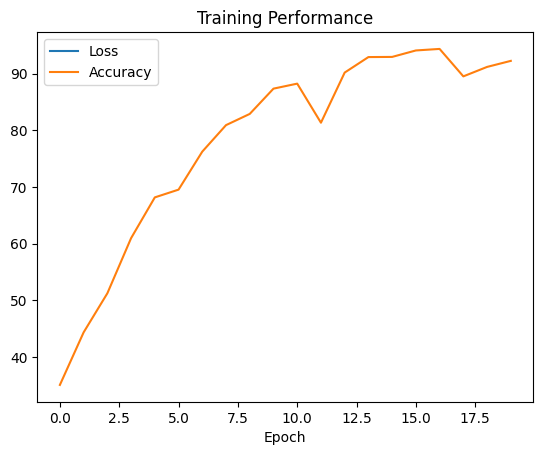

In [ ]:
# ===========================
# SEQ2SEQ ATTENTION STEMMER
# ===========================

# Here's a fully working sequence-to-sequence attention-based stemmer using PyTorch.
# Features:
# Encoder: BiLSTM
# Decoder: LSTM + Attention
# Loss: CrossEntropyLoss (ignores padding)
# Evaluation: Exact sequence match accuracy
# Output:
# encoder.pt, decoder.pt model files
# results.txt with loss/accuracy logs
# training_plot.png for visual training curves

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Google Colab Drive Mounting
from google.colab import drive
drive.mount('/content/drive')

# ===========================
# Constants and Setup
# ===========================
max_len = 25
chars = list("abcdefghijklmnopqrstuvwxyz‘ʼ")
char2idx = {c: i+1 for i, c in enumerate(chars)}
char2idx['<PAD>'] = 0
idx2char = {i: c for c, i in char2idx.items()}
vocab_size = len(char2idx)

def encode_word(word):
    encoded = [char2idx.get(c, 0) for c in word]
    encoded += [0] * (max_len - len(encoded))
    return encoded[:max_len]

def decode_seq(seq):
    return ''.join([idx2char[i] for i in seq if i != 0])

# ===========================
# Dataset Class
# ===========================
class StemDataset(Dataset):
    def __init__(self, filepath):
        self.pairs = []
        with open(filepath, 'r', encoding='utf8') as f:
            for line in f:
                if '/' in line:
                    stem, affix = line.strip().split('/')
                    word = stem + affix
                    self.pairs.append((encode_word(word), encode_word(stem)))

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        src, tgt = self.pairs[idx]
        return torch.tensor(src), torch.tensor(tgt)

# ===========================
# Encoder
# ===========================
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        self.lstm = nn.LSTM(embed_size, hidden_size, bidirectional=True, batch_first=True)

    def forward(self, src):
        embedded = self.embed(src)  # [B, T, E]
        outputs, (h, c) = self.lstm(embedded)
        return outputs, (h, c)

# ===========================
# Attention
# ===========================
class Attention(nn.Module):
    def __init__(self, enc_hidden_size, dec_hidden_size):
        super().__init__()
        self.attn = nn.Linear(enc_hidden_size + dec_hidden_size, 1)

    def forward(self, dec_hidden, enc_outputs):
        batch_size, seq_len, _ = enc_outputs.size()
        dec_hidden = dec_hidden.unsqueeze(1).repeat(1, seq_len, 1)
        energy = self.attn(torch.cat((enc_outputs, dec_hidden), dim=2)).squeeze(-1)
        attn_weights = torch.softmax(energy, dim=1)
        context = torch.bmm(attn_weights.unsqueeze(1), enc_outputs).squeeze(1)
        return context

# ===========================
# Decoder
# ===========================
class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_size, enc_hidden_size, dec_hidden_size):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        self.attn = Attention(enc_hidden_size, dec_hidden_size)
        self.lstm = nn.LSTM(embed_size + enc_hidden_size, dec_hidden_size, batch_first=True)
        self.fc = nn.Linear(dec_hidden_size, vocab_size)

    def forward(self, input_step, hidden, enc_outputs):
        embedded = self.embed(input_step).unsqueeze(1)  # [B, 1, E]
        context = self.attn(hidden[0][-1], enc_outputs).unsqueeze(1)  # [B, 1, H]
        rnn_input = torch.cat((embedded, context), dim=2)
        output, hidden = self.lstm(rnn_input, hidden)
        output = self.fc(output.squeeze(1))
        return output, hidden

# ===========================
# Training & Evaluation
# ===========================
def train_model(encoder, decoder, dataloader, optimizer, criterion, device):
    encoder.train()
    decoder.train()
    total_loss = 0
    for src, tgt in dataloader:
        src, tgt = src.to(device), tgt.to(device)
        optimizer.zero_grad()

        enc_outputs, (h, c) = encoder(src)
        dec_input = tgt[:, 0]
        dec_hidden = (h[0:1] + h[1:2], c[0:1] + c[1:2])
        loss = 0

        for t in range(1, tgt.size(1)):
            output, dec_hidden = decoder(dec_input, dec_hidden, enc_outputs)
            loss += criterion(output, tgt[:, t])
            dec_input = tgt[:, t]

        loss.backward()
        optimizer.step()
        total_loss += loss.item() / tgt.size(1)
    return total_loss / len(dataloader)

def evaluate_model(encoder, decoder, dataloader, device):
    encoder.eval()
    decoder.eval()
    total, correct = 0, 0
    with torch.no_grad():
        for src, tgt in dataloader:
            src, tgt = src.to(device), tgt.to(device)
            enc_outputs, (h, c) = encoder(src)
            dec_input = tgt[:, 0]
            dec_hidden = (h[0:1] + h[1:2], c[0:1] + c[1:2])
            outputs = []
            for t in range(1, tgt.size(1)):
                output, dec_hidden = decoder(dec_input, dec_hidden, enc_outputs)
                top1 = output.argmax(1)
                outputs.append(top1)
                dec_input = top1

            outputs = torch.stack(outputs, dim=1)
            correct += (outputs == tgt[:, 1:]).sum().item()
            total += (tgt[:, 1:] != 0).sum().item()
    return 100.0 * correct / total

# ===========================
# Main Execution
# ===========================
if __name__ == '__main__':
    file_path = '/content/drive/MyDrive/Colab Notebooks/Prog/Dataset1/output.txt'
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    dataset = StemDataset(file_path)
    train_set, test_set = train_test_split(dataset, test_size=0.2, random_state=42)
    train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_set, batch_size=32)

    embed_size = 64
    hidden_size = 128

    encoder = Encoder(vocab_size, embed_size, hidden_size).to(device)
    decoder = Decoder(vocab_size, embed_size, hidden_size * 2, hidden_size).to(device)

    optimizer = optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=0.001)
    criterion = nn.CrossEntropyLoss(ignore_index=0)

    losses, accs = [], []
    for epoch in range(20):
        loss = train_model(encoder, decoder, train_loader, optimizer, criterion, device)
        acc = evaluate_model(encoder, decoder, test_loader, device)
        losses.append(loss)
        accs.append(acc)
        print(f"Epoch {epoch+1}: Loss = {loss:.4f}, Accuracy = {acc:.2f}%")

    # Save Models
    torch.save(encoder.state_dict(), 'encoder.pt')
    torch.save(decoder.state_dict(), 'decoder.pt')

    # Save Results
    with open("results.txt", "w") as f:
        for i, (l, a) in enumerate(zip(losses, accs)):
            f.write(f"Epoch {i+1}: Loss={l:.4f}, Accuracy={a:.2f}%\n")

    # Plotting
    plt.plot(losses, label='Loss')
    plt.plot(accs, label='Accuracy')
    plt.legend()
    plt.xlabel("Epoch")
    plt.title("Training Performance")
    plt.savefig("training_plot.png")
    plt.show()
